# Stock Price Prediction & Anomaly Detection using LSTM
This notebook implements the data processing and modeling pipeline for predicting stock prices in the Indian banking sector (SBI, HDFC, ICICI).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Set plotting style
sns.set_theme(style="whitegrid")
%matplotlib inline

# Create results directory
os.makedirs("../results/plots", exist_ok=True)

## 1. Exploratory Data Analysis (EDA)
In this section, we load the raw historical data and visualize the closing price trends for each bank.

--- EDA for SBI ---
Data range: 2021-02-18 00:00:00 to 2026-02-18 00:00:00
Total records: 1243


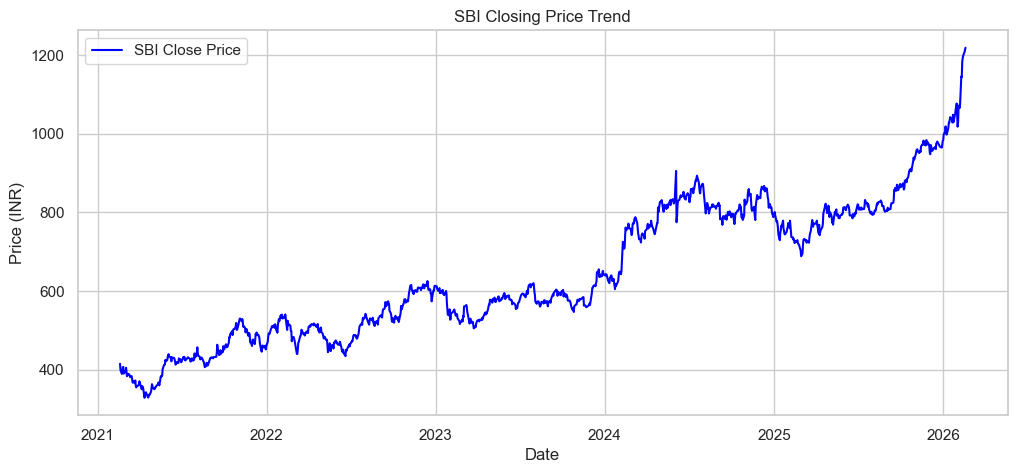

--- EDA for HDFC ---
Data range: 2021-02-18 00:00:00 to 2026-02-18 00:00:00
Total records: 1243


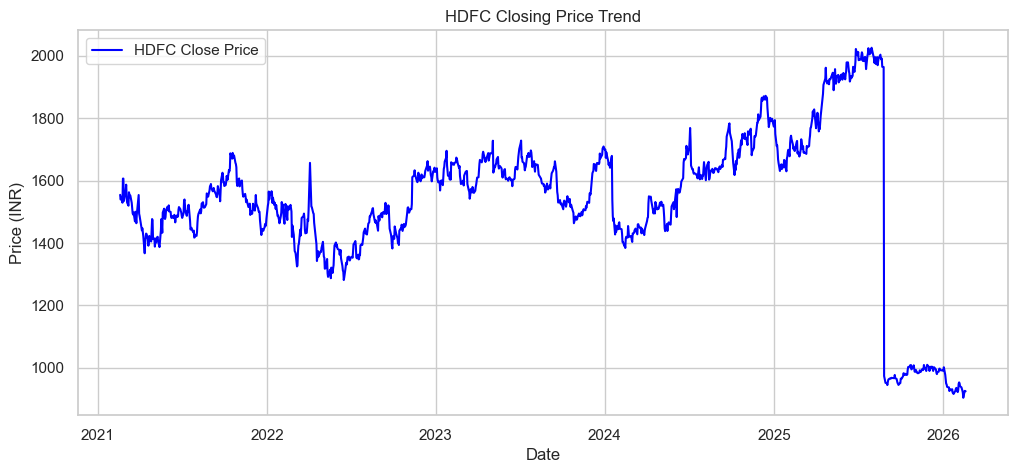

--- EDA for ICICI ---
Data range: 2021-02-18 00:00:00 to 2026-02-18 00:00:00
Total records: 1243


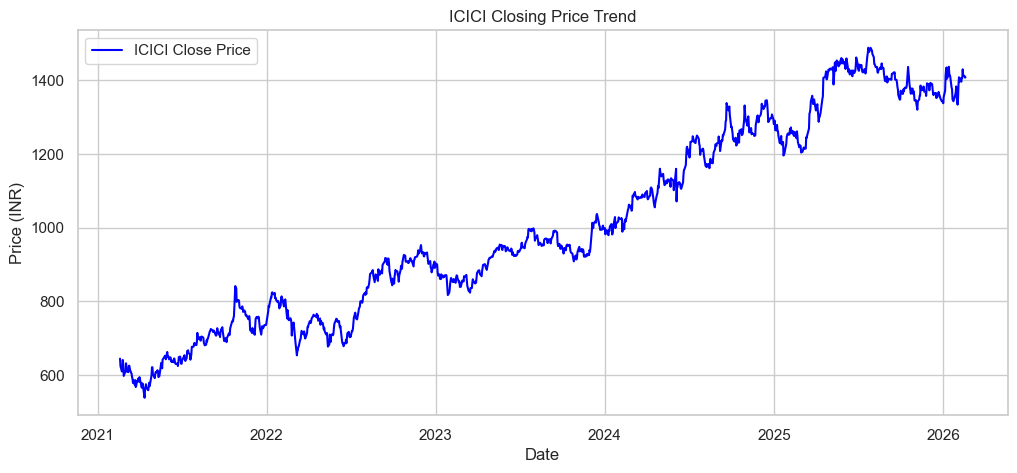

In [2]:
def perform_eda(file_path, bank_name):
    print(f"--- EDA for {bank_name} ---")
    df = pd.read_csv(file_path, thousands=',')
    
    # Preprocessing for EDA: Convert DATE to datetime and sort
    df['DATE'] = pd.to_datetime(df['DATE'], format='%d-%b-%Y')
    df = df.sort_values('DATE')
    
    print(f"Data range: {df['DATE'].min()} to {df['DATE'].max()}")
    print(f"Total records: {len(df)}")
    
    # Plotting Closing Price
    plt.figure(figsize=(12, 5))
    plt.plot(df['DATE'], df['CLOSE'], label=f'{bank_name} Close Price', color='blue')
    plt.title(f'{bank_name} Closing Price Trend')
    plt.xlabel('Date')
    plt.ylabel('Price (INR)')
    plt.legend()
    plt.show()

# Paths to raw data
banks = {'SBI': '../data/raw/SBI.csv', 'HDFC': '../data/raw/HDFC.csv', 'ICICI': '../data/raw/ICICI.csv'}

for name, path in banks.items():
    if os.path.exists(path):
        perform_eda(path, name)
    else:
        print(f"File not found: {path}")

## 2. Correlation Analysis
We analyze the correlation between the three banking stocks to understand their interdependencies.

--- Sectoral Correlation Analysis ---
Aligned records for correlation: 1241


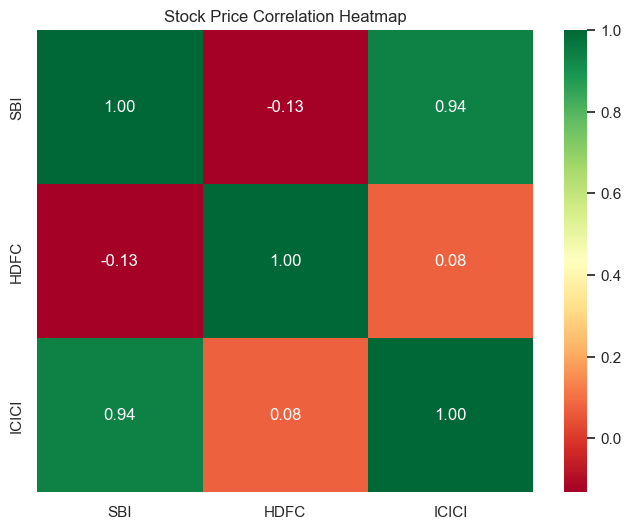

In [3]:
print("--- Sectoral Correlation Analysis ---")
close_prices = {}

for name, path in banks.items():
    if os.path.exists(path):
        df = pd.read_csv(path, thousands=',')
        df['DATE'] = pd.to_datetime(df['DATE'], format='%d-%b-%Y')
        df['CLOSE'] = pd.to_numeric(df['CLOSE'], errors='coerce')
        df = df.dropna().groupby('DATE').mean(numeric_only=True) # Handle duplicates
        close_prices[name] = df['CLOSE']

# Combine and calculate correlation matrix
combined_df = pd.concat(close_prices.values(), axis=1, keys=close_prices.keys(), join='inner')
print(f"Aligned records for correlation: {len(combined_df)}")

if not combined_df.empty:
    plt.figure(figsize=(8, 6))
    sns.heatmap(combined_df.corr(), annot=True, cmap='RdYlGn', fmt=".2f")
    plt.title('Stock Price Correlation Heatmap')
    plt.show()

## 3. Data Cleaning & Preprocessing
In this section, we clean the data for SBI (our primary target for prediction) and prepare it for the LSTM model.
Tasks:
- Drop unused columns.
- Normalize data using MinMaxScaler.
- Create sliding window sequences for LSTM input.

In [4]:
def prepare_data(file_path, target_col='CLOSE', window_size=60):
    print(f"--- Preparing data from {file_path} ---")
    df = pd.read_csv(file_path, thousands=',')
    
    # 1. Cleaning: Convert date, sort, and handle duplicates
    df['DATE'] = pd.to_datetime(df['DATE'], format='%d-%b-%Y')
    df = df.sort_values('DATE')
    df['CLOSE'] = pd.to_numeric(df['CLOSE'], errors='coerce')
    df = df.dropna(subset=[target_col])
    df = df.groupby('DATE').mean(numeric_only=True) # Ensure one record per day
    
    data = df[target_col].values.reshape(-1, 1)
    
    # 2. Normalization: Scale features to (0, 1) range for LSTM efficiency
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)
    
    # 3. Sliding Window Creation
    X, y = [], []
    for i in range(window_size, len(scaled_data)):
        X.append(scaled_data[i-window_size:i, 0])
        y.append(scaled_data[i, 0])
    
    X, y = np.array(X), np.array(y)
    X = np.reshape(X, (X.shape[0], X.shape[1], 1)) # LSTM input format: [samples, time steps, features]
    
    print(f"Processed {len(y)} sequences with window size {window_size}")
    return X, y, scaler

# Prepare training sequences for SBI stock
X_sbi, y_sbi, sbi_scaler = prepare_data('../data/raw/SBI.csv', window_size=60)

print(f"X_sbi shape: {X_sbi.shape}")
print(f"y_sbi shape: {y_sbi.shape}")

--- Preparing data from ../data/raw/SBI.csv ---
Processed 1181 sequences with window size 60
X_sbi shape: (1181, 60, 1)
y_sbi shape: (1181,)


## 4. LSTM Model Architecture
Here we define our LSTM model with 3 stacked LSTM layers and Dropout for regularization.

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

def create_lstm_model(input_shape):
    model = Sequential()
    # First LSTM layer
    model.add(LSTM(units=50, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    
    # Second LSTM layer
    model.add(LSTM(units=50, return_sequences=True))
    model.add(Dropout(0.2))
    
    # Third LSTM layer
    model.add(LSTM(units=50))
    model.add(Dropout(0.2))
    
    # Output layer
    model.add(Dense(units=1))
    
    # Compile the model with Adam optimizer and Mean Squared Error loss
    # Compile the model with Adam optimizer (lr=0.001) and Mean Squared Error loss
    from tensorflow.keras.optimizers import Adam
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mse', 'mae'])
    return model

input_shape = (X_sbi.shape[1], X_sbi.shape[2])
model = create_lstm_model(input_shape)
model.summary()

c:\Users\ronad\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Model Training Setup
Next, we configure the hyperparameters (epochs, batch size) and set up the callbacks for EarlyStopping and ModelCheckpoint. Then we train the model.

In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

epochs = 50
batch_size = 32

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('../results/sbi_lstm_model.h5', monitor='val_loss', save_best_only=True)

print("Starting model training for SBI...")
history = model.fit(
    X_sbi, y_sbi,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

Starting model training for SBI...


Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 0.0356 - mae: 0.1389 - mse: 0.0356

34/34 ━━━━━━━━━━━━━━━━━━━━ 36s 213ms/step - loss: 0.0155 - mae: 0.0857 - mse: 0.0155 - val_loss: 0.0167 - val_mae: 0.1191 - val_mse: 0.0167
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - loss: 0.0025 - mae: 0.0386 - mse: 0.0025

34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 347ms/step - loss: 0.0023 - mae: 0.0365 - mse: 0.0023 - val_loss: 0.0017 - val_mae: 0.0285 - val_mse: 0.0017
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 16s 458ms/step - loss: 0.0024 - mae: 0.0373 - mse: 0.0024 - val_loss: 0.0042 - val_mae: 0.0509 - val_mse: 0.0042
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - loss: 0.0023 - mae: 0.0366 - mse: 0.0023

34/34 ━━━━━━━━━━━━━━━━━━━━ 19s 396ms/step - loss: 0.0021 - mae: 0.0347 - mse: 0.0021 - val_loss: 0.0014 - val_mae: 0.0259 - val_mse: 0.0014
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 303ms/step - loss: 0.0019 - mae: 0.0339 - mse: 0.0019 - val_loss: 0.0029 - val_mae: 0.0397 - val_mse: 0.0029
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 19s 266ms/step - loss: 0.0019 - mae: 0.0326 - mse: 0.0019 - val_loss: 0.0047 - val_mae: 0.0558 - val_mse: 0.0047
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 216ms/step - loss: 0.0018 - mae: 0.0325 - mse: 0.0018 - val_loss: 0.0041 - val_mae: 0.0509 - val_mse: 0.0041
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 204ms/step - loss: 0.0017 - mae: 0.0313 - mse: 0.0017 - val_loss: 0.0022 - val_mae: 0.0325 - val_mse: 0.0022
Epoch 9/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - loss: 0.0021 - mae: 0.0346 - mse: 0.0021 - val_loss: 0.0063 - val_mae: 0.0691 - val_mse: 0.0063
Epoch 10/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - loss: 0.0023 - mae: 0.0374 - mse: 0.0023 - val_loss: 

## 6. Training History Plots
This block will graph the MSE (Mean Squared Error) and MAE (Mean Absolute Error) for both the training and validation sets to ensure the model converged without overfitting.

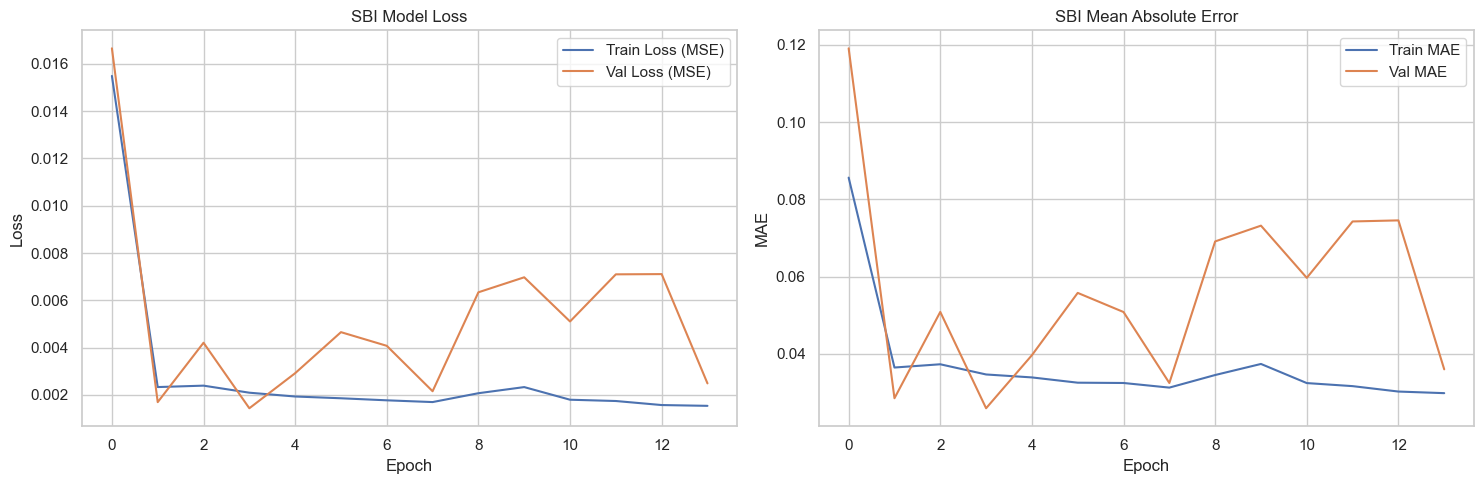

In [7]:
def plot_training_history(history, bank_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot MSE Loss
    ax1.plot(history.history['loss'], label='Train Loss (MSE)')
    ax1.plot(history.history['val_loss'], label='Val Loss (MSE)')
    ax1.set_title(f'{bank_name} Model Loss')
    ax1.set_ylabel('Loss')
    ax1.set_xlabel('Epoch')
    ax1.legend()
    
    # Plot MAE
    if 'mae' in history.history:
        ax2.plot(history.history['mae'], label='Train MAE')
        ax2.plot(history.history['val_mae'], label='Val MAE')
    elif 'mean_absolute_error' in history.history:
        ax2.plot(history.history['mean_absolute_error'], label='Train MAE')
        ax2.plot(history.history['val_mean_absolute_error'], label='Val MAE')
    ax2.set_title(f'{bank_name} Mean Absolute Error')
    ax2.set_ylabel('MAE')
    ax2.set_xlabel('Epoch')
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig(f'../results/plots/{bank_name.lower()}_training_history.png')
    plt.show()

plot_training_history(history, 'SBI')

## 7. Model Training for HDFC & ICICI
Here we expand our pipeline to the other two bank datasets, standardizing the process across both banks.


Training Pipeline for HDFC
--- Preparing data from ../data/raw/HDFC.csv ---
Processed 1181 sequences with window size 60


c:\Users\ronad\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 19s 212ms/step - loss: 0.0526 - mae: 0.1644 - mse: 0.0526 - val_loss: 0.0676 - val_mae: 0.2211 - val_mse: 0.0676
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 139ms/step - loss: 0.0112 - mae: 0.0798 - mse: 0.0112 - val_loss: 0.0530 - val_mae: 0.1736 - val_mse: 0.0530
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - loss: 0.0099 - mae: 0.0735 - mse: 0.0099 - val_loss: 0.0486 - val_mae: 0.1453 - val_mse: 0.0486
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - loss: 0.0084 - mae: 0.0673 - mse: 0.0084 - val_loss: 0.0502 - val_mae: 0.1400 - val_mse: 0.0502
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 134ms/step - loss: 0.0079 - mae: 0.0654 - mse: 0.0079 - val_loss: 0.0381 - val_mae: 0.1234 - val_mse: 0.0381
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 138ms/step - loss: 0.0082 - mae: 0.0669 - mse: 0.0082 - val_loss: 0.0516 - val_mae: 0.1516 - val_mse: 0.0516
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 132ms/step - loss: 0.0086 - mae: 0.0700 - mse: 0.0086 - va

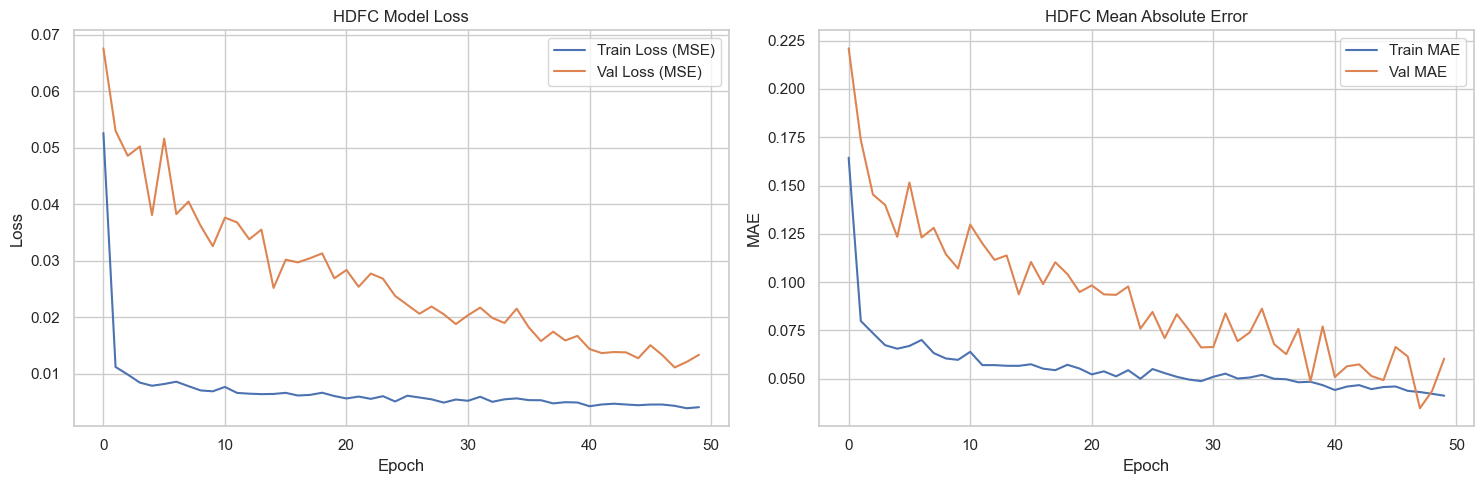


Training Pipeline for ICICI
--- Preparing data from ../data/raw/ICICI.csv ---
Processed 1181 sequences with window size 60


c:\Users\ronad\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 22s 176ms/step - loss: 0.0411 - mae: 0.1452 - mse: 0.0411 - val_loss: 0.0208 - val_mae: 0.1415 - val_mse: 0.0208
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 0.0056 - mae: 0.0556 - mse: 0.0056 - val_loss: 0.0016 - val_mae: 0.0333 - val_mse: 0.0016
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - loss: 0.0049 - mae: 0.0511 - mse: 0.0049 - val_loss: 0.0031 - val_mae: 0.0498 - val_mse: 0.0031
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 161ms/step - loss: 0.0052 - mae: 0.0521 - mse: 0.0052 - val_loss: 0.0010 - val_mae: 0.0268 - val_mse: 0.0010
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - loss: 0.0037 - mae: 0.0461 - mse: 0.0037 - val_loss: 0.0012 - val_mae: 0.0264 - val_mse: 0.0012
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0037 - mae: 0.0454 - mse: 0.0037 - val_loss: 9.4371e-04 - val_mae: 0.0243 - val_mse: 9.4371e-04
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0038 - mae: 0.0455 - mse: 0.00

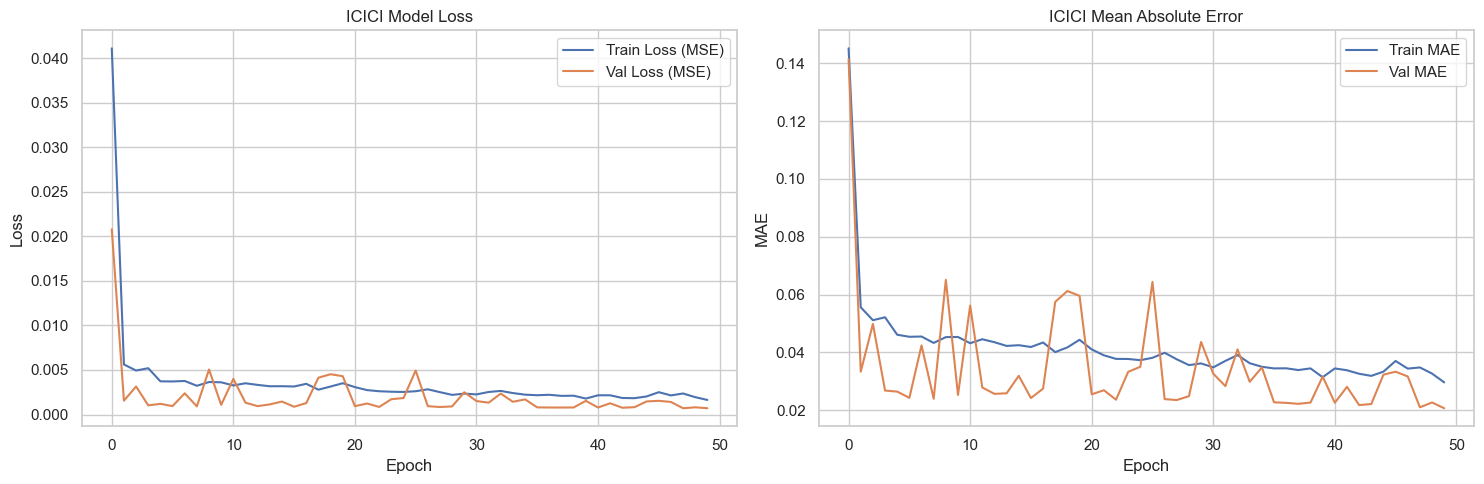

In [8]:
def train_and_evaluate(bank_name, file_path):
    print(f"\n{'='*40}")
    print(f"Training Pipeline for {bank_name}")
    print(f"{'='*40}")
    
    # 1. Prepare Data
    X, y, scaler = prepare_data(file_path, window_size=60)
    
    # 2. Compile Model
    input_shape = (X.shape[1], X.shape[2])
    model = create_lstm_model(input_shape)
    
    # 3. Setup Callbacks
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    checkpoint_path = f'../results/{bank_name.lower()}_lstm_model.keras'
    model_checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True)
    
    # 4. Train Model
    history = model.fit(
        X, y,
        epochs=50,
        batch_size=32,
        validation_split=0.1,
        callbacks=[early_stopping, model_checkpoint],
        verbose=1
    )
    
    # 5. Plot History
    plot_training_history(history, bank_name)
    
    return model, scaler, history

# Run for HDFC
hdfc_model, hdfc_scaler, hdfc_hist = train_and_evaluate('HDFC', '../data/raw/HDFC.csv')

# Run for ICICI
icici_model, icici_scaler, icici_hist = train_and_evaluate('ICICI', '../data/raw/ICICI.csv')

## 8. Prediction Generation
This block runs the trained models on the test split of our data to verify they can generalize predictions, and then uses inverse scaling to convert the predictions back into standard INR format.


Generating Predictions for SBI
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 183ms/step


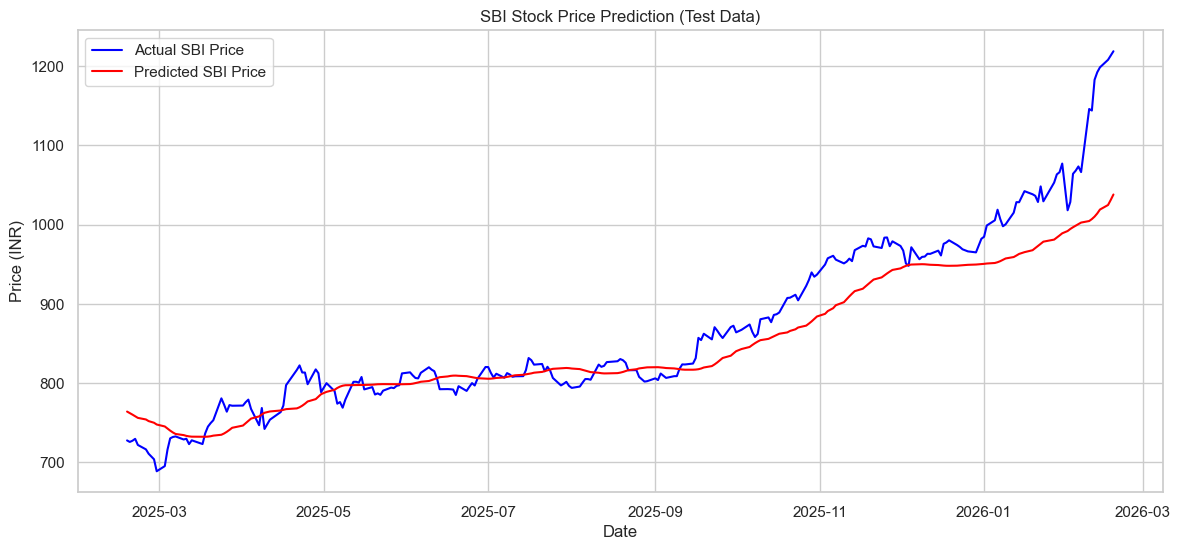


Generating Predictions for HDFC
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 214ms/step


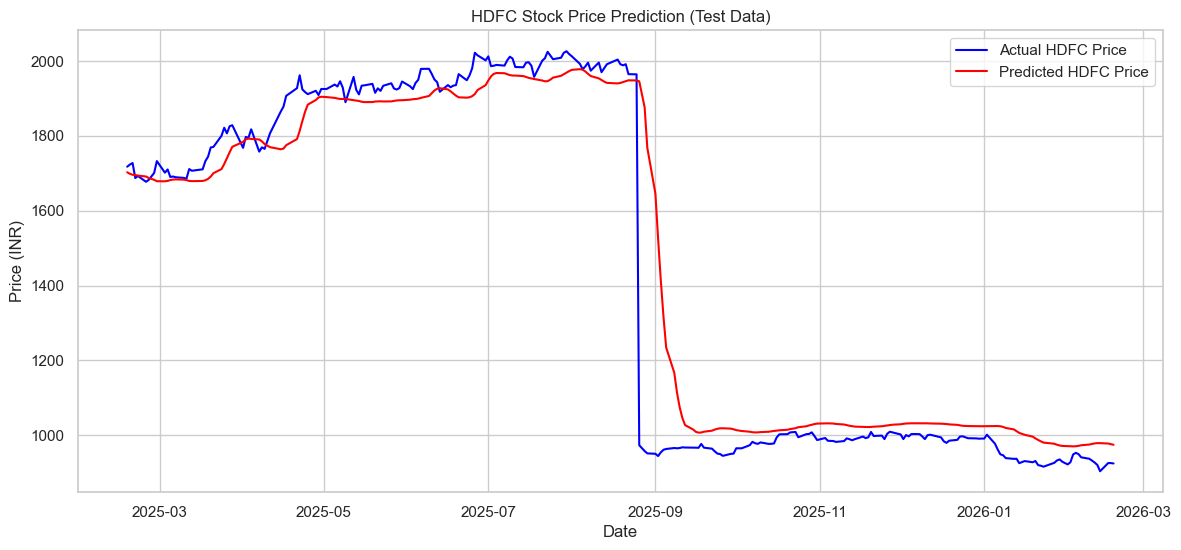


Generating Predictions for ICICI


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 183ms/step


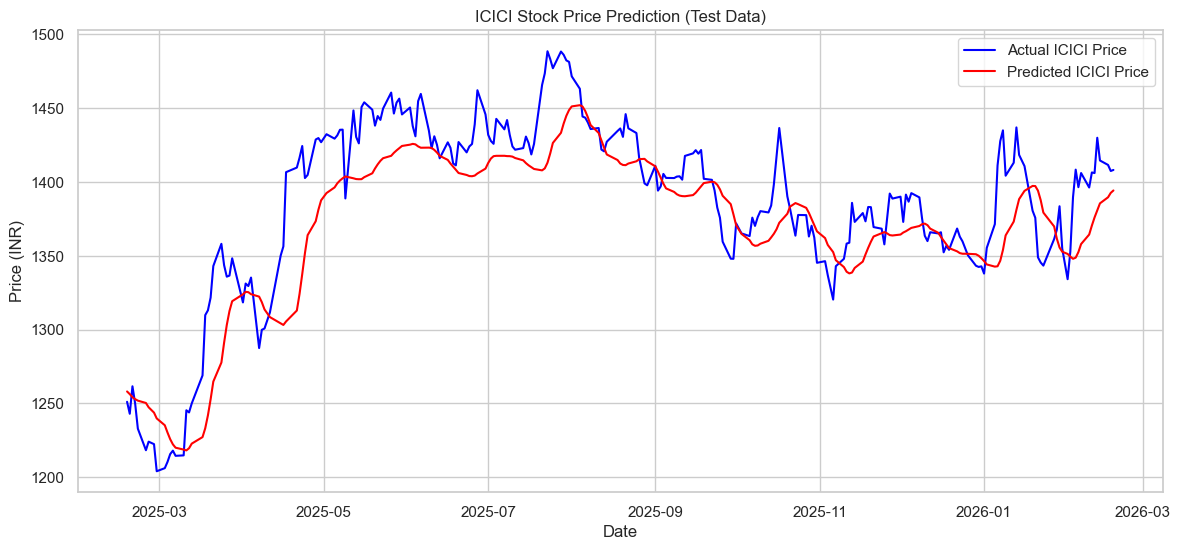

In [9]:
from tensorflow.keras.models import load_model

def test_data(file_path, window_size=60):
    df = pd.read_csv(file_path, thousands=',')
    df['DATE'] = pd.to_datetime(df['DATE'], format='%d-%b-%Y')
    df = df.sort_values('DATE')
    df['CLOSE'] = pd.to_numeric(df['CLOSE'], errors='coerce')
    df = df.dropna(subset=['CLOSE'])
    df = df.groupby('DATE').mean(numeric_only=True)
    data = df['CLOSE'].values.reshape(-1, 1)
    
    # Train-test split (80-20)
    train_size = int(len(data) * 0.8)
    test_data = data[train_size - window_size:]
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(data[:train_size]) # Fit only on train
    scaled_test = scaler.transform(test_data)
    
    X_test, y_test = [], []
    for i in range(window_size, len(scaled_test)):
        X_test.append(scaled_test[i-window_size:i, 0])
        y_test.append(scaled_test[i, 0])
        
    X_test, y_test = np.array(X_test), np.array(y_test)
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
    
    # Also return dates for plotting
    dates = df.index[train_size:].values
    return X_test, y_test, scaler, dates

def predict_and_plot(bank_name, file_path):
    print(f"\n{'='*40}")
    print(f"Generating Predictions for {bank_name}")
    print(f"{'='*40}")
    
    X_test, y_test, scaler, dates = test_data(file_path)
    
    # Load model and predict
    model_path = f'../results/{bank_name.lower()}_lstm_model.keras'
    try:
        model = load_model(model_path)
    except FileNotFoundError:
        print(f"Error: Model {model_path} not found. Train first.")
        return None, None, None
        
    predictions = model.predict(X_test)
    
    # Inverse transform
    predictions_inv = scaler.inverse_transform(predictions)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
    
    # Plot Predictions vs Actuals
    plt.figure(figsize=(14, 6))
    plt.plot(dates, y_test_inv, color='blue', label=f'Actual {bank_name} Price')
    plt.plot(dates, predictions_inv, color='red', label=f'Predicted {bank_name} Price')
    plt.title(f'{bank_name} Stock Price Prediction (Test Data)')
    plt.xlabel('Date')
    plt.ylabel('Price (INR)')
    plt.legend()
    plt.savefig(f'../results/plots/{bank_name.lower()}_predictions.png')
    plt.show()
    
    return predictions_inv, y_test_inv, dates

# Generate for all banks
sbi_pred, sbi_actual, sbi_dates = predict_and_plot('SBI', '../data/raw/SBI.csv')
hdfc_pred, hdfc_actual, hdfc_dates = predict_and_plot('HDFC', '../data/raw/HDFC.csv')
icici_pred, icici_actual, icici_dates = predict_and_plot('ICICI', '../data/raw/ICICI.csv')

## 9. Performance Metrics
This section calculates standard evaluation metrics (MSE, MAE, RMSE, MAPE) for each bank to quantify the model's accuracy.

In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def calculate_metrics(y_true, y_pred, bank_name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    return {
        'Bank': bank_name,
        'MSE': mse,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE (%)': mape
    }

metrics_list = []
if sbi_pred is not None: metrics_list.append(calculate_metrics(sbi_actual, sbi_pred, 'SBI'))
if hdfc_pred is not None: metrics_list.append(calculate_metrics(hdfc_actual, hdfc_pred, 'HDFC'))
if icici_pred is not None: metrics_list.append(calculate_metrics(icici_actual, icici_pred, 'ICICI'))

metrics_df = pd.DataFrame(metrics_list)
print("\n--- Performance Metrics Comparison ---")
print(metrics_df)
metrics_df.to_csv('../results/performance_metrics.csv', index=False)
print("\nMetrics saved to results/performance_metrics.csv")


--- Performance Metrics Comparison ---
    Bank           MSE        MAE        RMSE  MAPE (%)
0    SBI   1960.482388  30.176106   44.277335  3.227643
1   HDFC  17240.776253  61.231806  131.304136  5.298792
2  ICICI   1013.135138  24.533133   31.829784  1.759990

Metrics saved to results/performance_metrics.csv


## 10. LSTM Autoencoder for Anomaly Detection (Week 5)
This section implements an LSTM Autoencoder to detect anomalies in stock price movements. The model is trained to reconstruct normal sequences; high reconstruction error indicates an anomaly.

In [11]:
from tensorflow.keras.layers import RepeatVector, TimeDistributed

def create_autoencoder(input_shape):
    model = Sequential([
        # Encoder
        LSTM(64, activation='relu', input_shape=input_shape, return_sequences=True),
        LSTM(32, activation='relu', return_sequences=False),
        RepeatVector(input_shape[0]),
        # Decoder
        LSTM(32, activation='relu', return_sequences=True),
        LSTM(64, activation='relu', return_sequences=True),
        TimeDistributed(Dense(input_shape[1]))
    ])
    model.compile(optimizer='adam', loss='mae')
    return model

print("LSTM Autoencoder architecture defined.")

LSTM Autoencoder architecture defined.


In [12]:
def prepare_ae_data(file_path, window_size=60):
    # We need the full scaled data as 3D sequences for the Autoencoder
    df = pd.read_csv(file_path, thousands=',')
    df['DATE'] = pd.to_datetime(df['DATE'], format='%d-%b-%Y')
    df = df.sort_values('DATE')
    df['CLOSE'] = pd.to_numeric(df['CLOSE'], errors='coerce')
    df = df.dropna(subset=['CLOSE'])
    df = df.groupby('DATE').mean(numeric_only=True)
    data = df['CLOSE'].values.reshape(-1, 1)
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)
    
    X = []
    for i in range(window_size, len(scaled_data)):
        X.append(scaled_data[i-window_size:i])
    
    X = np.array(X)
    return X, scaler, df.index[window_size:]

print("Autoencoder data preparation function defined.")

Autoencoder data preparation function defined.


## 11. Anomaly Detection Logic and Visualization
This block identifies anomalies by calculating the reconstruction loss. We set a threshold based on the loss distribution (e.g., mean + 3 standard deviations) and flag anything above it.


Detecting Anomalies for SBI


37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 159ms/step
Threshold set at: 0.0873
Number of anomalies detected: 14


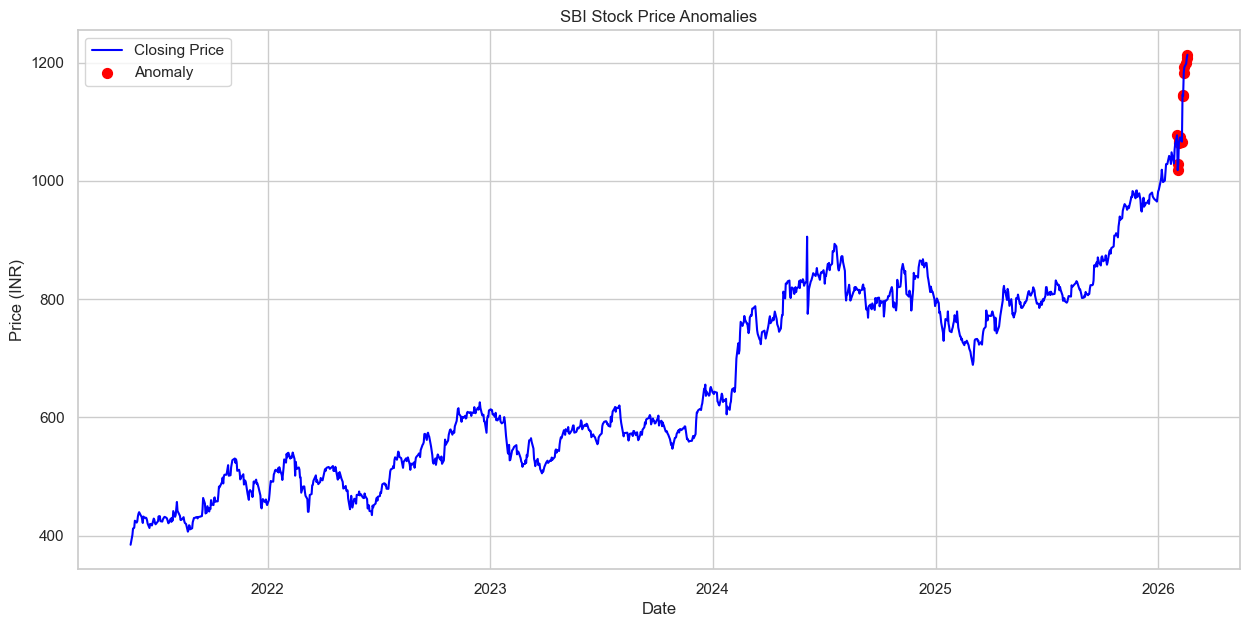


Detecting Anomalies for HDFC
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step
Threshold set at: 0.2521
Number of anomalies detected: 32


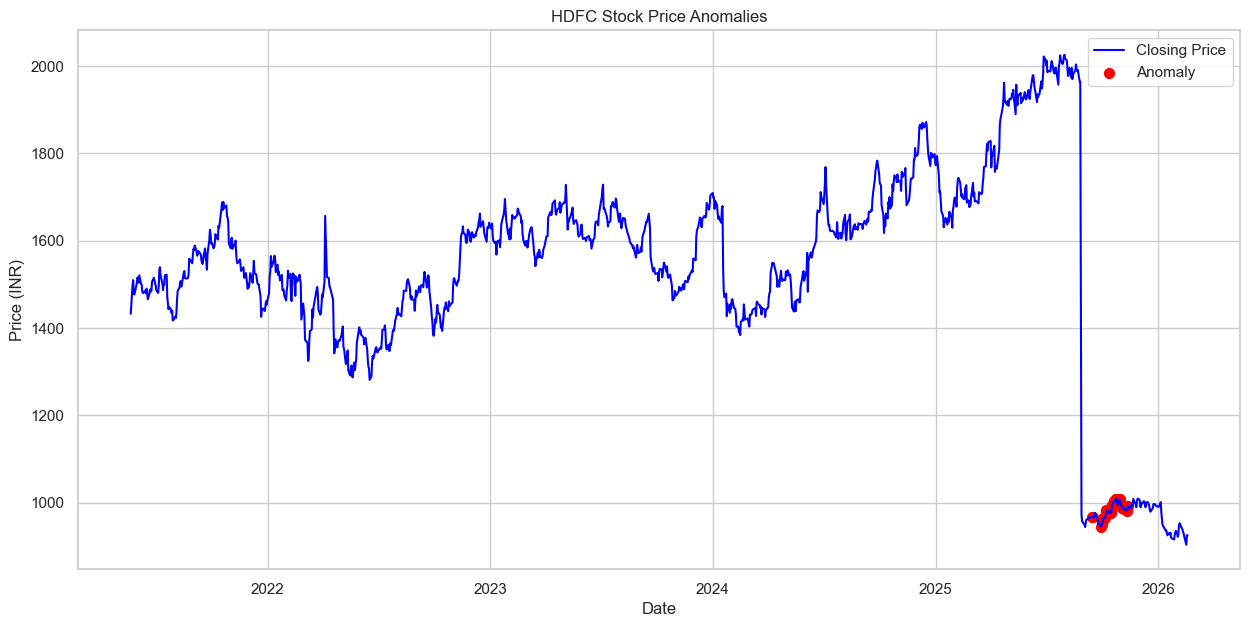


Detecting Anomalies for ICICI
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step
Threshold set at: 0.0621
Number of anomalies detected: 18


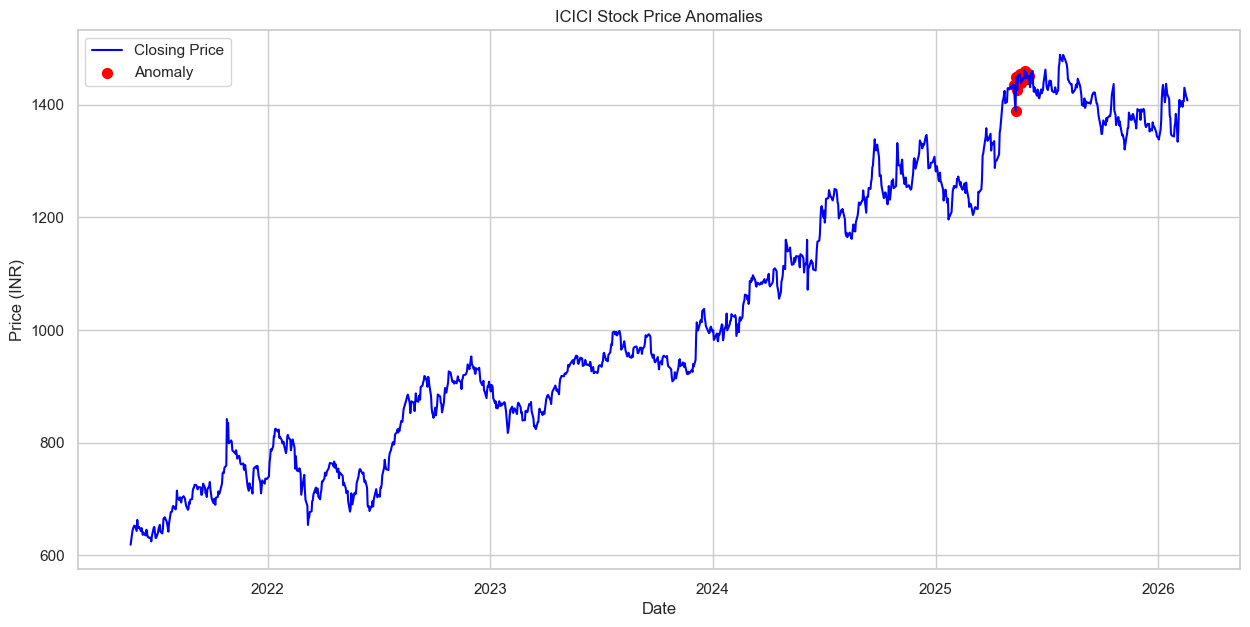

In [13]:
from tensorflow.keras.models import load_model

def detect_anomalies(bank_name, file_path):
    print(f"\n{'='*40}")
    print(f"Detecting Anomalies for {bank_name}")
    print(f"{'='*40}")
    
    X, scaler, dates = prepare_ae_data(file_path)
    model_path = f'../results/models/{bank_name.lower()}_autoencoder.keras'
    model = load_model(model_path)
    
    # Predict (reconstruct)
    X_pred = model.predict(X)
    
    # Calculate reconstruction MAE loss
    reconstruction_loss = np.mean(np.abs(X_pred - X), axis=(1, 2))
    
    # Define threshold (mean + 3*std is often used for outlier detection)
    threshold = np.mean(reconstruction_loss) + 3 * np.std(reconstruction_loss)
    print(f"Threshold set at: {threshold:.4f}")
    
    # Identify anomalies
    anomalies = reconstruction_loss > threshold
    print(f"Number of anomalies detected: {np.sum(anomalies)}")
    
    # Plot
    # Get actual closing prices corresponding to the sequences (last element of each sequence)
    actual_prices = scaler.inverse_transform(X[:, -1, :])
    anomaly_prices = actual_prices[anomalies]
    anomaly_dates = dates[anomalies]
    
    plt.figure(figsize=(15, 7))
    plt.plot(dates, actual_prices, label='Closing Price', color='blue')
    plt.scatter(anomaly_dates, anomaly_prices, color='red', label='Anomaly', s=50)
    plt.title(f'{bank_name} Stock Price Anomalies')
    plt.xlabel('Date')
    plt.ylabel('Price (INR)')
    plt.legend()
    plt.savefig(f'../results/plots/{bank_name.lower()}_anomalies.png')
    plt.show()
    
    return anomaly_dates, anomaly_prices, threshold

# Run for all banks
sbi_anom_dates, sbi_anom_prices, sbi_thresh = detect_anomalies('SBI', '../data/raw/SBI.csv')
hdfc_anom_dates, hdfc_anom_prices, hdfc_thresh = detect_anomalies('HDFC', '../data/raw/HDFC.csv')
icici_anom_dates, icici_anom_prices, icici_thresh = detect_anomalies('ICICI', '../data/raw/ICICI.csv')